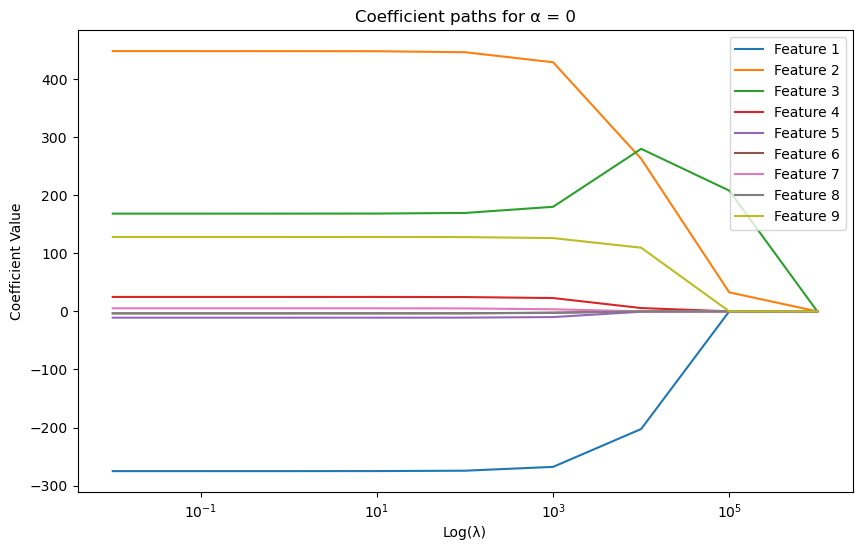

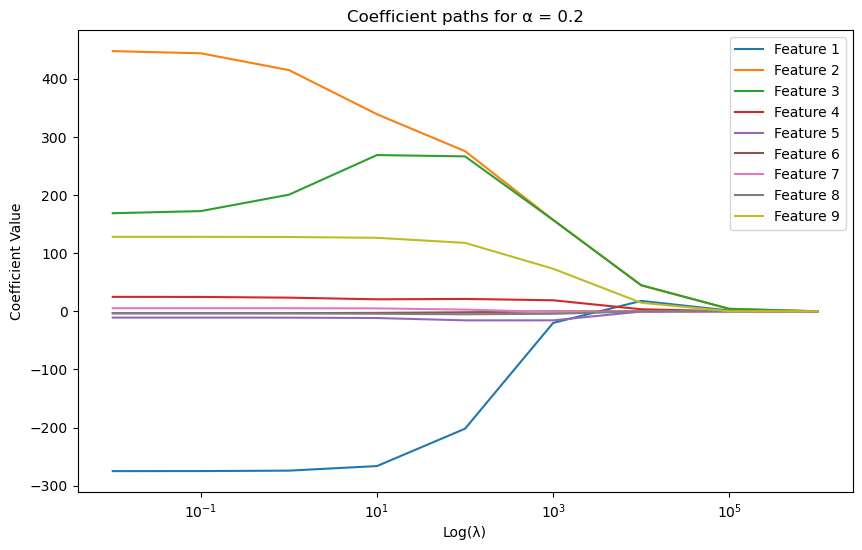

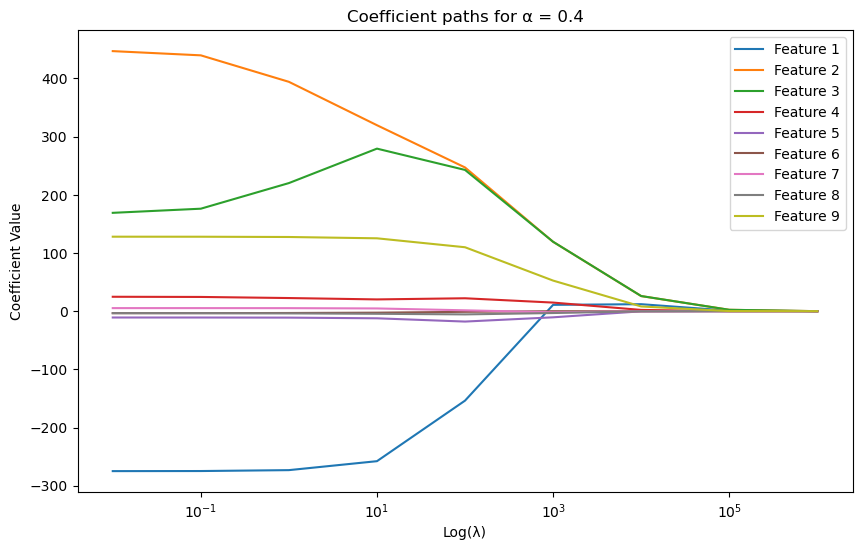

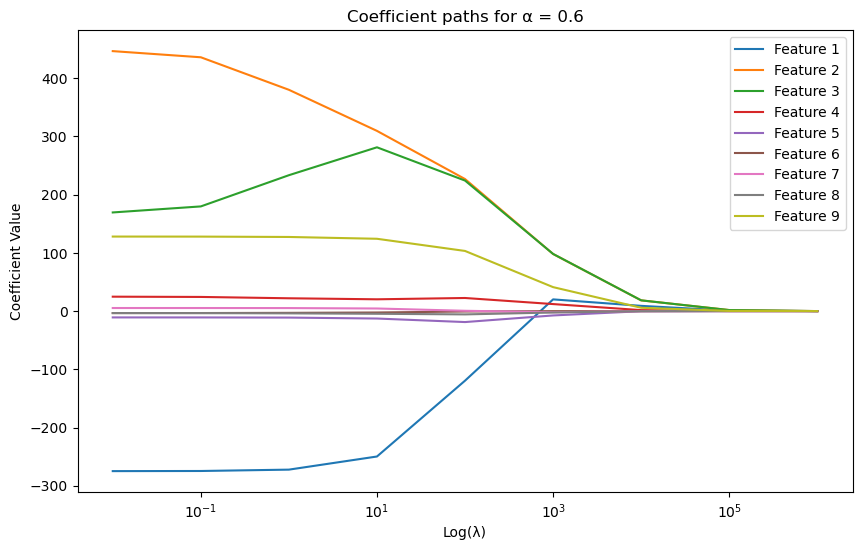

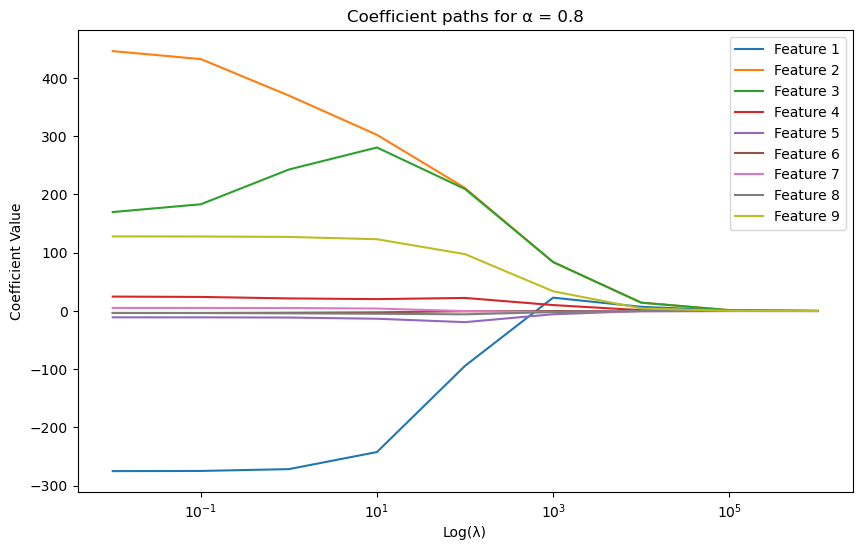

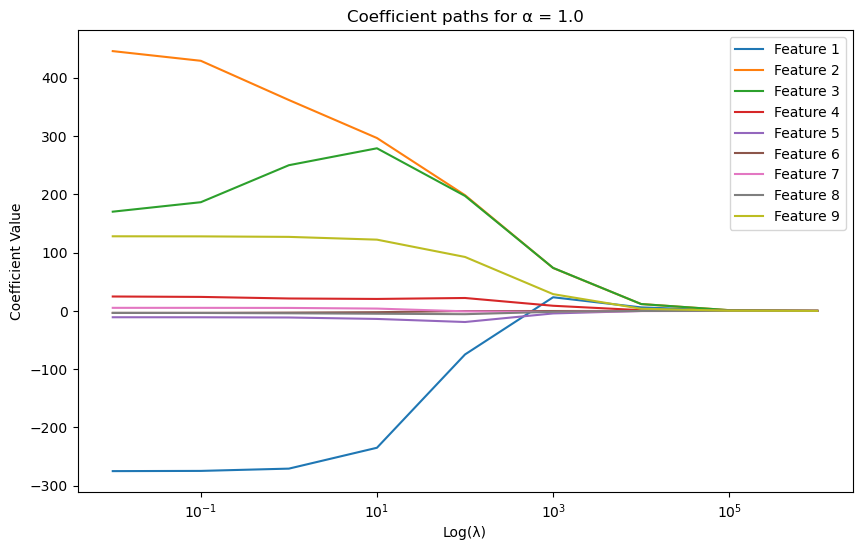

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load and preprocess data
filename = "Credit_N400_p9.csv"
advertising_df = pd.read_csv(filename)

# Separate target and features
x_features_df = advertising_df.copy(deep=True)
y_features_df = x_features_df.pop("Balance")

# Convert categorical variables to dummy variables
x_features_df = pd.get_dummies(x_features_df, columns=["Gender", "Married", "Student"], drop_first=True, dtype=int)

# Standardize features and target
X_standardized = (x_features_df - x_features_df.mean()) / x_features_df.std()
y_standardized = y_features_df - y_features_df.mean()

# Convert to numpy arrays for efficiency
X = X_standardized.to_numpy()
y = y_standardized.to_numpy()

# Define algorithm parameters
alpha_set = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
lambda_set = [10**-2, 10**-1, 10**0, 10**1, 10**2, 10**3, 10**4, 10**5, 10**6]
k_folds = 5
max_iters = 1000

# Initialize holders for cross-validation results
cross_validation_account_final = []
vector_parameter_beta_final = []
cross_validation_beta_account_final = []

def cross_validate_elastic_net(X, y, alpha_set, lambda_set, k_folds=5, max_iters=1000):
    fold_size = len(y) // k_folds
    errors = np.zeros((len(alpha_set), len(lambda_set)))

    for alpha_idx, alpha in enumerate(alpha_set):
        alpha_errors = []
        alpha_betas = []

        for lambda_idx, lambd in enumerate(lambda_set):
            fold_errors = []
            fold_betas = []

            for fold in range(k_folds):
                # Split data for validation and training
                start, end = fold * fold_size, (fold + 1) * fold_size
                X_val, y_val = X[start:end], y[start:end]
                X_train = np.concatenate([X[:start], X[end:]])
                y_train = np.concatenate([y[:start], y[end:]])

                # Precompute b_k for training set
                b_k = np.sum(X_train ** 2, axis=0)
                
                # Initialize beta for coordinate descent
                beta = np.random.uniform(-1, 1, X_train.shape[1])
                
                # Perform coordinate descent for the elastic net
                for _ in range(max_iters):
                    for k in range(len(beta)):
                        # Calculate r_k using the current beta
                        r_k = y_train - X_train.dot(beta) + X_train[:, k] * beta[k]
                        a_k = X_train[:, k].dot(r_k)
                        
                        # Update beta[k] using the elastic net formula
                        if a_k > lambd * (1 - alpha) / 2:
                            beta[k] = (a_k - lambd * (1 - alpha) / 2) / (b_k[k] + lambd * alpha)
                        elif a_k < -lambd * (1 - alpha) / 2:
                            beta[k] = (a_k + lambd * (1 - alpha) / 2) / (b_k[k] + lambd * alpha)
                        else:
                            beta[k] = 0

                # Validation error
                y_pred_val = X_val.dot(beta)
                mse = np.mean((y_val - y_pred_val) ** 2)
                fold_errors.append(mse)
                fold_betas.append(beta.copy())

            # Append fold results for current alpha-lambda pair
            alpha_errors.append(np.mean(fold_errors))
            alpha_betas.append(np.mean(fold_betas, axis=0))
        
        # Store results for current alpha in global arrays
        cross_validation_account_final.append(alpha_errors)
        vector_parameter_beta_final.append(alpha_betas)
    
    return cross_validation_account_final, vector_parameter_beta_final


# Run cross-validation
cross_validation_account_final, vector_parameter_beta_final = cross_validate_elastic_net(X, y, alpha_set, lambda_set)

# Plot Task 1: Coefficient paths
def plot_coefficients_vs_lambda(coefficients, alpha, lambda_set):
    plt.figure(figsize=(10, 6))
    for i, coeff in enumerate(coefficients.T):
        plt.semilogx(lambda_set, coeff, label=f"Feature {i+1}")
    plt.xlabel('Log(λ)')
    plt.ylabel('Coefficient Value')
    plt.title(f"Coefficient paths for α = {alpha}")
    plt.legend(loc='best')
    plt.show()

# Plot for each alpha
for alpha_idx, alpha in enumerate(alpha_set):
    coeffs = np.array(vector_parameter_beta_final[alpha_idx])
    plot_coefficients_vs_lambda(coeffs, alpha, lambda_set)